In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

print("Libraries loaded successfully.")
print("Current folder:", os.getcwd())

Libraries loaded successfully.
Current folder: C:\Users\Dell\Desktop\NYC_ED_DataJam\notebooks


In [5]:
print(os.listdir("../data"))

['ACSDT5Y2024.B19013-Data.csv', 'Hospital_General_Information.csv', 'Timely_and_Effective_Care-Hospital.csv']


In [7]:
cms_ed = pd.read_csv(
    "../data/Timely_and_Effective_Care-Hospital.csv",
    dtype={
        "Facility ID": str,
        "ZIP Code": str
    },
    low_memory=False
)

hospital_info = pd.read_csv(
    "../data/Hospital_General_Information.csv",
    dtype={
        "Facility ID": str,
        "ZIP Code": str
    },
    low_memory=False
)

acs_income = pd.read_csv(
    "../data/ACSDT5Y2024.B19013-Data.csv",
    low_memory=False
)

In [8]:
print("CMS Timely & Effective Care:", cms_ed.shape)
print("Hospital General Information:", hospital_info.shape)
print("ACS Income:", acs_income.shape)

CMS Timely & Effective Care: (138084, 16)
Hospital General Information: (5419, 38)
ACS Income: (33773, 5)


In [9]:
print("Number of OP_18a rows:",
      (cms_ed["Measure ID"] == "OP_18a").sum())

print("\nMeasure name:")
print(
    cms_ed.loc[
        cms_ed["Measure ID"] == "OP_18a",
        "Measure Name"
    ].unique()
)

Number of OP_18a rows: 4658

Measure name:
<StringArray>
['Average (median) time all patients spent in the emergency department before leaving from the visit, including psychiatric/mental health patients and patients who were transferred to another facility. A lower number of minutes is better']
Length: 1, dtype: str


In [10]:
rows_before = len(cms_ed)

op18a = cms_ed[
    cms_ed["Measure ID"] == "OP_18a"
].copy()

rows_after = len(op18a)

print("Rows before:", rows_before)
print("Rows after OP_18a filter:", rows_after)
print("Rows removed:", rows_before - rows_after)

Rows before: 138084
Rows after OP_18a filter: 4658
Rows removed: 133426


In [11]:
op18a[
    [
        "Facility ID",
        "Facility Name",
        "City/Town",
        "State",
        "ZIP Code",
        "County/Parish",
        "Measure ID",
        "Measure Name",
        "Score",
        "Sample",
        "Start Date",
        "End Date"
    ]
].head(10)

,Facility ID,Facility Name,City/Town,State,ZIP Code,County/Parish,Measure ID,Measure Name,Score,Sample,Start Date,End Date
10,010001,SOUTHEAST HEALTH MEDICAL CENTER,DOTHAN,AL,36301,HOUSTON,OP_18a,Average (median) time all patients spent in th...,214,405,10/01/2024,09/30/2025
40,010005,MARSHALL MEDICAL CENTERS,BOAZ,AL,35957,MARSHALL,OP_18a,Average (median) time all patients spent in th...,146,1214,10/01/2024,09/30/2025
70,010006,NORTH ALABAMA MEDICAL CENTER,FLORENCE,AL,35630,LAUDERDALE,OP_18a,Average (median) time all patients spent in th...,158,376,10/01/2024,09/30/2025
100,010007,MIZELL MEMORIAL HOSPITAL,OPP,AL,36467,COVINGTON,OP_18a,Average (median) time all patients spent in th...,137,1103,10/01/2024,09/30/2025
130,010011,ST. VINCENT'S EAST,BIRMINGHAM,AL,35235,JEFFERSON,OP_18a,Average (median) time all patients spent in th...,168,369,10/01/2024,09/30/2025
160,010012,DEKALB REGIONAL MEDICAL CENTER,FORT PAYNE,AL,35968,DE KALB,OP_18a,Average (median) time all patients spent in th...,174,410,10/01/2024,09/30/2025
190,010016,SHELBY BAPTIST MEDICAL CENTER,ALABASTER,AL,35007,SHELBY,OP_18a,Average (median) time all patients spent in th...,180,439,10/01/2024,09/30/2025
220,010019,HELEN KELLER HOSPITAL,SHEFFIELD,AL,35660,COLBERT,OP_18a,Average (median) time all patients spent in th...,189,373,10/01/2024,09/30/2025
250,010021,DALE MEDICAL CENTER,OZARK,AL,36360,DALE,OP_18a,Average (median) time all patients spent in th...,152,380,10/01/2024,09/30/2025
280,010022,FLOYD CHEROKEE MEDICAL CENTER,CENTRE,AL,35960,CHEROKEE,OP_18a,Average (median) time all patients spent in th...,127,436,10/01/2024,09/30/2025


In [12]:
print(
    op18a[
        ["Start Date", "End Date"]
    ].drop_duplicates()
)

    Start Date    End Date
10  10/01/2024  09/30/2025


In [13]:
print("Number of rows:", len(op18a))
print("Unique Facility IDs:", op18a["Facility ID"].nunique())
print(
    "Duplicate Facility IDs:",
    op18a["Facility ID"].duplicated().sum()
)

Number of rows: 4658
Unique Facility IDs: 4658
Duplicate Facility IDs: 0


In [14]:
ny_counties = (
    op18a.loc[op18a["State"] == "NY", "County/Parish"]
    .dropna()
    .sort_values()
    .unique()
)

print(ny_counties)

<StringArray>
[      'ALBANY',     'ALLEGANY',        'BRONX',       'BROOME',
  'CATTARAUGUS',       'CAYUGA',   'CHAUTAUQUA',      'CHEMUNG',
     'CHENANGO',      'CLINTON',     'COLUMBIA',     'CORTLAND',
     'DELAWARE',     'DUTCHESS',         'ERIE',        'ESSEX',
     'FRANKLIN',       'FULTON',      'GENESEE',     'HERKIMER',
    'JEFFERSON',        'KINGS',        'LEWIS',   'LIVINGSTON',
      'MADISON',       'MONROE',   'MONTGOMERY',       'NASSAU',
     'NEW YORK',      'NIAGARA',       'ONEIDA',     'ONONDAGA',
      'ONTARIO',       'ORANGE',      'ORLEANS',       'OSWEGO',
       'OTSEGO',       'PUTNAM',       'QUEENS',   'RENSSELAER',
     'RICHMOND',     'ROCKLAND',     'SARATOGA',  'SCHENECTADY',
    'SCHOHARIE',     'SCHUYLER', 'ST. LAWRENCE',      'STEUBEN',
      'SUFFOLK',     'SULLIVAN',     'TOMPKINS',       'ULSTER',
       'WARREN',        'WAYNE',  'WESTCHESTER',      'WYOMING',
        'YATES']
Length: 57, dtype: str


In [15]:
nyc_counties = [
    "NEW YORK",
    "KINGS",
    "QUEENS",
    "BRONX",
    "RICHMOND"
]

rows_before_nyc = len(op18a)

nyc_op18a = op18a[
    (op18a["State"] == "NY") &
    (
        op18a["County/Parish"]
        .str.strip()
        .str.upper()
        .isin(nyc_counties)
    )
].copy()

rows_after_nyc = len(nyc_op18a)

print("Rows before NYC filter:", rows_before_nyc)
print("Rows after NYC filter:", rows_after_nyc)
print("Rows removed:", rows_before_nyc - rows_after_nyc)

Rows before NYC filter: 4658
Rows after NYC filter: 33
Rows removed: 4625


In [16]:
print(
    nyc_op18a["County/Parish"]
    .value_counts()
)


County/Parish
NEW YORK    11
KINGS        9
QUEENS       6
BRONX        5
RICHMOND     2
Name: count, dtype: int64


In [17]:
nyc_op18a[
    [
        "Facility ID",
        "Facility Name",
        "City/Town",
        "State",
        "ZIP Code",
        "County/Parish",
        "Score"
    ]
].sort_values(
    ["County/Parish", "Facility Name"]
).reset_index(drop=True)

,Facility ID,Facility Name,City/Town,State,ZIP Code,County/Parish,Score
0,330009,BRONXCARE HOSPITAL CENTER,BRONX,NY,10456,BRONX,190
1,330127,JACOBI MEDICAL CENTER,BRONX,NY,10461,BRONX,224
2,330080,LINCOLN MEDICAL & MENTAL HEALTH CENTER,BRONX,NY,10451,BRONX,253
3,330059,MONTEFIORE MEDICAL CENTER,BRONX,NY,10467,BRONX,196
4,330399,ST BARNABAS HOSPITAL,BRONX,NY,10457,BRONX,326
5,330233,BROOKDALE HOSPITAL MEDICAL CENTER,BROOKLYN,NY,11212,KINGS,228
6,330056,BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS,BROOKLYN,NY,11201,KINGS,203
7,330202,KINGS COUNTY HOSPITAL CENTER,BROOKLYN,NY,11203,KINGS,271
8,330194,MAIMONIDES MEDICAL CENTER,BROOKLYN,NY,11219,KINGS,216
9,330019,"NEW YORK COMMUNITY HOSPITAL OF BROOKLYN, INC.",BROOKLYN,NY,11229,KINGS,196


In [21]:
nyc_op18a["Score_raw"] = nyc_op18a["Score"]

In [22]:
nyc_op18a[["Facility Name", "Score", "Score_raw"]].head()

,Facility Name,Score,Score_raw
81700,BRONXCARE HOSPITAL CENTER,190,190
81790,JAMAICA HOSPITAL MEDICAL CENTER,228,228
81820,"NEW YORK COMMUNITY HOSPITAL OF BROOKLYN, INC.",196,196
81880,MOUNT SINAI HOSPITAL,250,250
81940,RICHMOND UNIVERSITY MEDICAL CENTER,200,200


In [23]:
nyc_op18a["ED_LOS_minutes"] = pd.to_numeric(
    nyc_op18a["Score_raw"],
    errors="coerce"
)

nyc_op18a[
    nyc_op18a["ED_LOS_minutes"].isna()
][["Facility Name", "Score_raw", "ED_LOS_minutes"]]

,Facility Name,Score_raw,ED_LOS_minutes
82690,NY EYE AND EAR INFIRMARY OF MOUNT SINAI,Not Available,NaN
84843,HOSPITAL FOR SPECIAL SURGERY,Not Available,NaN


In [25]:
nyc_op18a[
    nyc_op18a["ED_LOS_minutes"].isna()
][
    ["Facility Name", "Score_raw", "Sample", "Footnote"]
]

,Facility Name,Score_raw,Sample,Footnote
82690,NY EYE AND EAR INFIRMARY OF MOUNT SINAI,Not Available,Not Available,5
84843,HOSPITAL FOR SPECIAL SURGERY,Not Available,Not Available,5


In [26]:
print("Total NYC hospitals:", len(nyc_op18a))
print("Hospitals with numeric OP_18a:",
      nyc_op18a["ED_LOS_minutes"].notna().sum())
print("Hospitals with unavailable OP_18a:",
      nyc_op18a["ED_LOS_minutes"].isna().sum())

Total NYC hospitals: 33
Hospitals with numeric OP_18a: 31
Hospitals with unavailable OP_18a: 2


In [27]:
nyc_ed_clean = nyc_op18a[
    nyc_op18a["ED_LOS_minutes"].notna()
].copy()

print("Rows in clean NYC ED dataset:", len(nyc_ed_clean))

Rows in clean NYC ED dataset: 31


In [28]:
print("Rows:", len(nyc_ed_clean))
print("Unique Facility IDs:", nyc_ed_clean["Facility ID"].nunique())
print("Duplicate Facility IDs:", nyc_ed_clean["Facility ID"].duplicated().sum())

Rows: 31
Unique Facility IDs: 31
Duplicate Facility IDs: 0


In [29]:
nyc_ed_clean[["Facility Name", "ZIP Code"]].sort_values("ZIP Code")

,Facility Name,ZIP Code
83470,MOUNT SINAI BETH ISRAEL,10003
84100,NYU LANGONE HOSPITALS,10016
84010,BELLEVUE HOSPITAL CENTER,10016
82120,MOUNT SINAI WEST,10019
81880,MOUNT SINAI HOSPITAL,10029
83920,METROPOLITAN HOSPITAL CENTER,10029
84550,HARLEM HOSPITAL CENTER,10037
82720,NEW YORK-PRESBYTERIAN HOSPITAL,10065
82960,LENOX HILL HOSPITAL,10075
83350,STATEN ISLAND UNIVERSITY HOSPITAL,10305


In [30]:
nyc_ed_clean["ZIP Code"] = (
    nyc_ed_clean["ZIP Code"]
    .astype(str)
    .str.zfill(5)
)

print(nyc_ed_clean["ZIP Code"].head())
print("ZIP lengths:", nyc_ed_clean["ZIP Code"].str.len().value_counts())


81700    10456
81790    11418
81820    11229
81880    10029
81940    10310
Name: ZIP Code, dtype: str
ZIP lengths: ZIP Code
5    31
Name: count, dtype: int64


In [31]:
hospital_info.columns.tolist()

['Facility ID',
 'Facility Name',
 'Address',
 'City/Town',
 'State',
 'ZIP Code',
 'County/Parish',
 'Telephone Number',
 'Hospital Type',
 'Hospital Ownership',
 'Emergency Services',
 'Meets criteria for birthing friendly designation',
 'Hospital overall rating',
 'Hospital overall rating footnote',
 'MORT Group Measure Count',
 'Count of Facility MORT Measures',
 'Count of MORT Measures Better',
 'Count of MORT Measures No Different',
 'Count of MORT Measures Worse',
 'MORT Group Footnote',
 'Safety Group Measure Count',
 'Count of Facility Safety Measures',
 'Count of Safety Measures Better',
 'Count of Safety Measures No Different',
 'Count of Safety Measures Worse',
 'Safety Group Footnote',
 'READM Group Measure Count',
 'Count of Facility READM Measures',
 'Count of READM Measures Better',
 'Count of READM Measures No Different',
 'Count of READM Measures Worse',
 'READM Group Footnote',
 'Pt Exp Group Measure Count',
 'Count of Facility Pt Exp Measures',
 'Pt Exp Group Footno

In [32]:
print("Hospital info rows:", len(hospital_info))
print("Unique Facility IDs:", hospital_info["Facility ID"].nunique())
print("Duplicate Facility IDs:", hospital_info["Facility ID"].duplicated().sum())

Hospital info rows: 5419
Unique Facility IDs: 5419
Duplicate Facility IDs: 0


In [33]:
matched_ids = nyc_ed_clean["Facility ID"].isin(
    hospital_info["Facility ID"]
)

print("NYC hospitals:", len(nyc_ed_clean))
print("Matched in Hospital General Information:", matched_ids.sum())
print("Unmatched:", (~matched_ids).sum())

NYC hospitals: 31
Matched in Hospital General Information: 31
Unmatched: 0


In [34]:
hospital_covariates = hospital_info[
    [
        "Facility ID",
        "Hospital Type",
        "Hospital Ownership",
        "Emergency Services",
        "Hospital overall rating"
    ]
].copy()

hospital_covariates.head()

,Facility ID,Hospital Type,Hospital Ownership,Emergency Services,Hospital overall rating
0,010001,Acute Care Hospitals,Government - Hospital District or Authority,Yes,4
1,010005,Acute Care Hospitals,Government - Hospital District or Authority,Yes,3
2,010006,Acute Care Hospitals,Proprietary,Yes,2
3,010007,Acute Care Hospitals,Voluntary non-profit - Private,Yes,1
4,010011,Acute Care Hospitals,Voluntary non-profit - Private,Yes,3


In [35]:
nyc_ed_hosp = nyc_ed_clean.merge(
    hospital_covariates,
    on="Facility ID",
    how="left",
    validate="one_to_one"
)

print("Rows before merge:", len(nyc_ed_clean))
print("Rows after merge:", len(nyc_ed_hosp))

Rows before merge: 31
Rows after merge: 31


In [36]:
nyc_ed_hosp[
    [
        "Facility Name",
        "Hospital Type",
        "Hospital Ownership",
        "Emergency Services",
        "Hospital overall rating"
    ]
].head()

,Facility Name,Hospital Type,Hospital Ownership,Emergency Services,Hospital overall rating
0,BRONXCARE HOSPITAL CENTER,Acute Care Hospitals,Voluntary non-profit - Private,Yes,1
1,JAMAICA HOSPITAL MEDICAL CENTER,Acute Care Hospitals,Voluntary non-profit - Private,Yes,1
2,"NEW YORK COMMUNITY HOSPITAL OF BROOKLYN, INC.",Acute Care Hospitals,Voluntary non-profit - Private,Yes,1
3,MOUNT SINAI HOSPITAL,Acute Care Hospitals,Voluntary non-profit - Private,Yes,4
4,RICHMOND UNIVERSITY MEDICAL CENTER,Acute Care Hospitals,Voluntary non-profit - Private,Yes,1


In [37]:
nyc_ed_hosp[
    [
        "Hospital Type",
        "Hospital Ownership",
        "Emergency Services",
        "Hospital overall rating"
    ]
].isna().sum()


Hospital Type              0
Hospital Ownership         0
Emergency Services         0
Hospital overall rating    0
dtype: int64

In [38]:
print("Hospital Type:")
print(nyc_ed_hosp["Hospital Type"].value_counts())

print("\nHospital Ownership:")
print(nyc_ed_hosp["Hospital Ownership"].value_counts())

print("\nEmergency Services:")
print(nyc_ed_hosp["Emergency Services"].value_counts())

print("\nHospital Overall Rating:")
print(nyc_ed_hosp["Hospital overall rating"].value_counts())

Hospital Type:
Hospital Type
Acute Care Hospitals    31
Name: count, dtype: int64

Hospital Ownership:
Hospital Ownership
Voluntary non-profit - Private    18
Government - Local                 7
Voluntary non-profit - Other       3
Government - State                 2
Voluntary non-profit - Church      1
Name: count, dtype: int64

Emergency Services:
Emergency Services
Yes    31
Name: count, dtype: int64

Hospital Overall Rating:
Hospital overall rating
2    12
1     9
5     4
3     4
4     2
Name: count, dtype: int64


In [39]:
edv = cms_ed[
    (cms_ed["Measure ID"] == "EDV") &
    (cms_ed["Facility ID"].isin(nyc_ed_hosp["Facility ID"]))
].copy()

print("EDV rows:", len(edv))

edv[
    ["Facility ID", "Facility Name", "Score", "Start Date", "End Date"]
].sort_values("Facility Name")


EDV rows: 31


,Facility ID,Facility Name,Score,Start Date,End Date
84000,330204,BELLEVUE HOSPITAL CENTER,very high,01/01/2024,12/31/2024
81690,330009,BRONXCARE HOSPITAL CENTER,very high,01/01/2024,12/31/2024
84390,330233,BROOKDALE HOSPITAL MEDICAL CENTER,very high,01/01/2024,12/31/2024
82230,330056,BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS,high,01/01/2024,12/31/2024
83070,330128,ELMHURST HOSPITAL CENTER,very high,01/01/2024,12/31/2024
83730,330193,FLUSHING HOSPITAL MEDICAL CENTER,medium,01/01/2024,12/31/2024
84540,330240,HARLEM HOSPITAL CENTER,very high,01/01/2024,12/31/2024
83040,330127,JACOBI MEDICAL CENTER,very high,01/01/2024,12/31/2024
81780,330014,JAMAICA HOSPITAL MEDICAL CENTER,very high,01/01/2024,12/31/2024
83940,330202,KINGS COUNTY HOSPITAL CENTER,Not Available,01/01/2024,12/31/2024


In [40]:
print(edv["Score"].value_counts(dropna=False))

Score
very high        22
high              4
Not Available     3
medium            2
Name: count, dtype: int64


In [41]:
edv_small = edv[
    ["Facility ID", "Score"]
].rename(
    columns={"Score": "ED_Volume_Category"}
)

nyc_ed_hosp = nyc_ed_hosp.merge(
    edv_small,
    on="Facility ID",
    how="left",
    validate="one_to_one"
)

print("Rows after EDV merge:", len(nyc_ed_hosp))
print(nyc_ed_hosp["ED_Volume_Category"].value_counts(dropna=False))

Rows after EDV merge: 31
ED_Volume_Category
very high        22
high              4
Not Available     3
medium            2
Name: count, dtype: int64


In [42]:
op22 = cms_ed[
    (cms_ed["Measure ID"] == "OP_22") &
    (cms_ed["Facility ID"].isin(nyc_ed_hosp["Facility ID"]))
].copy()

print("OP_22 rows:", len(op22))

op22[
    ["Facility ID", "Facility Name", "Score", "Start Date", "End Date"]
].sort_values("Facility Name")

OP_22 rows: 31


,Facility ID,Facility Name,Score,Start Date,End Date
84014,330204,BELLEVUE HOSPITAL CENTER,1,01/01/2024,12/31/2024
81704,330009,BRONXCARE HOSPITAL CENTER,3,01/01/2024,12/31/2024
84404,330233,BROOKDALE HOSPITAL MEDICAL CENTER,3,01/01/2024,12/31/2024
82244,330056,BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS,3,01/01/2024,12/31/2024
83084,330128,ELMHURST HOSPITAL CENTER,2,01/01/2024,12/31/2024
83744,330193,FLUSHING HOSPITAL MEDICAL CENTER,2,01/01/2024,12/31/2024
84554,330240,HARLEM HOSPITAL CENTER,3,01/01/2024,12/31/2024
83054,330127,JACOBI MEDICAL CENTER,2,01/01/2024,12/31/2024
81794,330014,JAMAICA HOSPITAL MEDICAL CENTER,3,01/01/2024,12/31/2024
83954,330202,KINGS COUNTY HOSPITAL CENTER,Not Available,01/01/2024,12/31/2024


In [43]:
print(op22["Measure Name"].unique())

<StringArray>
['Left before being seen']
Length: 1, dtype: str


In [44]:
op22[
    ["Facility Name", "Score", "Sample", "Footnote"]
].head(10)

,Facility Name,Score,Sample,Footnote
81704,BRONXCARE HOSPITAL CENTER,3,125885,NaN
81794,JAMAICA HOSPITAL MEDICAL CENTER,3,111995,NaN
81824,"NEW YORK COMMUNITY HOSPITAL OF BROOKLYN, INC.",Not Available,Not Available,5
81884,MOUNT SINAI HOSPITAL,2,175125,NaN
81944,RICHMOND UNIVERSITY MEDICAL CENTER,0,55857,NaN
82124,MOUNT SINAI WEST,2,137377,NaN
82214,NEW YORK-PRESBYTERIAN/QUEENS,6,100301,NaN
82244,BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS,3,57078,NaN
82334,MONTEFIORE MEDICAL CENTER,1,305503,NaN
82514,LINCOLN MEDICAL & MENTAL HEALTH CENTER,9,29063,NaN


In [45]:
op22["LWBS_percent"] = pd.to_numeric(
    op22["Score"],
    errors="coerce"
)

print("Numeric OP_22 values:", op22["LWBS_percent"].notna().sum())
print("Unavailable OP_22 values:", op22["LWBS_percent"].isna().sum())

Numeric OP_22 values: 28
Unavailable OP_22 values: 3


In [46]:
op22_small = op22[
    ["Facility ID", "LWBS_percent"]
].copy()

nyc_ed_hosp = nyc_ed_hosp.merge(
    op22_small,
    on="Facility ID",
    how="left",
    validate="one_to_one"
)

print("Rows after OP_22 merge:", len(nyc_ed_hosp))
print("Missing LWBS values:", nyc_ed_hosp["LWBS_percent"].isna().sum())

Rows after OP_22 merge: 31
Missing LWBS values: 3


In [47]:
print(acs_income.columns.tolist())
acs_income.head()

['GEO_ID', 'NAME', 'B19013_001E', 'B19013_001M', 'Unnamed: 4']


,GEO_ID,NAME,B19013_001E,B19013_001M,Unnamed: 4
0,Geography,Geographic Area Name,Estimate!!Median household income in the past ...,Margin of Error!!Median household income in th...,NaN
1,860Z200US00601,ZCTA5 00601,19454,1546,NaN
2,860Z200US00602,ZCTA5 00602,21420,1811,NaN
3,860Z200US00603,ZCTA5 00603,20933,1650,NaN
4,860Z200US00606,ZCTA5 00606,20992,3212,NaN


In [48]:
acs_clean = acs_income.iloc[1:].copy()

print("Rows before:", len(acs_income))
print("Rows after removing descriptive row:", len(acs_clean))

Rows before: 33773
Rows after removing descriptive row: 33772


In [49]:
acs_clean["ZCTA"] = (
    acs_clean["NAME"]
    .str.replace("ZCTA5 ", "", regex=False)
    .str.strip()
)

acs_clean[["NAME", "ZCTA"]].head()

,NAME,ZCTA
1,ZCTA5 00601,00601
2,ZCTA5 00602,00602
3,ZCTA5 00603,00603
4,ZCTA5 00606,00606
5,ZCTA5 00610,00610


In [50]:
print(acs_clean["ZCTA"].str.len().value_counts())

ZCTA
5    33772
Name: count, dtype: int64


In [51]:
print("Unique ZCTAs:", acs_clean["ZCTA"].nunique())
print("Duplicate ZCTAs:", acs_clean["ZCTA"].duplicated().sum())

Unique ZCTAs: 33772
Duplicate ZCTAs: 0


In [52]:
acs_clean["Median_Household_Income"] = pd.to_numeric(
    acs_clean["B19013_001E"],
    errors="coerce"
)

print("Numeric income values:",
      acs_clean["Median_Household_Income"].notna().sum())

print("Missing/non-numeric income values:",
      acs_clean["Median_Household_Income"].isna().sum())

Numeric income values: 30414
Missing/non-numeric income values: 3358


In [53]:
zip_match = nyc_ed_hosp["ZIP Code"].isin(acs_clean["ZCTA"])

print("NYC hospitals:", len(nyc_ed_hosp))
print("ZIPs matched to ACS ZCTA:", zip_match.sum())
print("Unmatched ZIPs:", (~zip_match).sum())

NYC hospitals: 31
ZIPs matched to ACS ZCTA: 31
Unmatched ZIPs: 0


In [54]:
hospital_acs_check = acs_clean[
    acs_clean["ZCTA"].isin(nyc_ed_hosp["ZIP Code"])
].copy()

print("Matched ACS rows:", len(hospital_acs_check))

print(
    "Missing income among hospital ZCTAs:",
    hospital_acs_check["Median_Household_Income"].isna().sum()
)

Matched ACS rows: 27
Missing income among hospital ZCTAs: 0


In [55]:
print("Hospitals:", len(nyc_ed_hosp))
print("Unique hospital ZIP codes:", nyc_ed_hosp["ZIP Code"].nunique())
print("Matched ACS ZCTAs:", len(hospital_acs_check))

Hospitals: 31
Unique hospital ZIP codes: 27
Matched ACS ZCTAs: 27


In [56]:



# 2. Add borough names
borough_map = {
    "NEW YORK": "Manhattan",
    "KINGS": "Brooklyn",
    "QUEENS": "Queens",
    "BRONX": "Bronx",
    "RICHMOND": "Staten Island"
}

nyc_ed_hosp["Borough"] = (
    nyc_ed_hosp["County/Parish"]
    .str.strip()
    .str.upper()
    .map(borough_map)
)


# 3. Clean ACS margin of error
acs_clean["Income_MOE"] = pd.to_numeric(
    acs_clean["B19013_001M"],
    errors="coerce"
)


# 4. Keep only ACS columns needed for our project
acs_merge = acs_clean[
    [
        "ZCTA",
        "Median_Household_Income",
        "Income_MOE"
    ]
].copy()

# Rename ZCTA so it matches hospital ZIP column
acs_merge = acs_merge.rename(
    columns={"ZCTA": "ZIP Code"}
)


# 5. Merge hospital ZIP -> ACS ZCTA income
rows_before_merge = len(nyc_ed_hosp)

final_clean = nyc_ed_hosp.merge(
    acs_merge,
    on="ZIP Code",
    how="left",
    validate="many_to_one"
)

rows_after_merge = len(final_clean)


# 6. Standardize a few variables
final_clean["Hospital overall rating"] = pd.to_numeric(
    final_clean["Hospital overall rating"],
    errors="coerce"
)

final_clean["ED_Volume_Category"] = final_clean[
    "ED_Volume_Category"
].replace("Not Available", np.nan)


# 7. Verify ACS matching
matched_income = final_clean["Median_Household_Income"].notna().sum()
unmatched_income = final_clean["Median_Household_Income"].isna().sum()
match_percent = matched_income / len(final_clean) * 100


# 8. Print cleaning summary
print("\n================ CLEANING SUMMARY ================")

print("Rows before ACS merge:", rows_before_merge)
print("Rows after ACS merge:", rows_after_merge)

print("\nHospitals with ACS income:", matched_income)
print("Hospitals without ACS income:", unmatched_income)
print(f"ACS income match rate: {match_percent:.1f}%")

print("\nUnique Facility IDs:",
      final_clean["Facility ID"].nunique())

print("Duplicate Facility IDs:",
      final_clean["Facility ID"].duplicated().sum())

print("\nBorough counts:")
print(final_clean["Borough"].value_counts())

print("\nMissing values in important variables:")
print(
    final_clean[
        [
            "ED_LOS_minutes",
            "Median_Household_Income",
            "Hospital overall rating",
            "Hospital Ownership",
            "ED_Volume_Category",
            "LWBS_percent"
        ]
    ].isna().sum()
)


# 9. Create a compact project dataset
analysis_columns = [
    "Facility ID",
    "Facility Name",
    "Address",
    "City/Town",
    "ZIP Code",
    "County/Parish",
    "Borough",
    "ED_LOS_minutes",
    "Median_Household_Income",
    "Income_MOE",
    "Hospital Type",
    "Hospital Ownership",
    "Hospital overall rating",
    "Emergency Services",
    "ED_Volume_Category",
    "LWBS_percent",
    "Start Date",
    "End Date"
]

final_dataset = final_clean[analysis_columns].copy()


# 10. Save cleaned dataset
final_dataset.to_csv(
    "../output/nyc_ed_datajam_clean.csv",
    index=False
)

print("\nSaved cleaned dataset:")
print("../output/nyc_ed_datajam_clean.csv")

print("\nFinal dataset shape:", final_dataset.shape)


================ CLEANING SUMMARY ================
Rows before ACS merge: 31
Rows after ACS merge: 31

Hospitals with ACS income: 31
Hospitals without ACS income: 0
ACS income match rate: 100.0%

Unique Facility IDs: 31
Duplicate Facility IDs: 0

Borough counts:
Borough
Brooklyn         9
Manhattan        9
Queens           6
Bronx            5
Staten Island    2
Name: count, dtype: int64

Missing values in important variables:
ED_LOS_minutes             0
Median_Household_Income    0
Hospital overall rating    0
Hospital Ownership         0
ED_Volume_Category         3
LWBS_percent               3
dtype: int64

Saved cleaned dataset:
../output/nyc_ed_datajam_clean.csv

Final dataset shape: (31, 18)


In [57]:
# ============================================================
# STEP 9 — EXPLORATORY DATA ANALYSIS
# ============================================================

import pandas as pd
import numpy as np

# ------------------------------------------------------------
# 1. Helper function for descriptive statistics
# ------------------------------------------------------------

def descriptive_stats(series):
    s = series.dropna()

    return pd.Series({
        "N": len(s),
        "Mean": s.mean(),
        "Median": s.median(),
        "Std Dev": s.std(),
        "Minimum": s.min(),
        "Q1": s.quantile(0.25),
        "Q3": s.quantile(0.75),
        "Maximum": s.max()
    })


# ------------------------------------------------------------
# 2. Main-variable descriptive statistics
# ------------------------------------------------------------

main_stats = pd.DataFrame({
    "ED Length of Stay (minutes)":
        descriptive_stats(final_dataset["ED_LOS_minutes"]),

    "Hospital-Neighborhood Median Household Income ($)":
        descriptive_stats(final_dataset["Median_Household_Income"])
}).T

print("================================================")
print("MAIN VARIABLE DESCRIPTIVE STATISTICS")
print("================================================")

display(main_stats.round(2))


# ------------------------------------------------------------
# 3. Hospital overall rating
# ------------------------------------------------------------

print("\n================================================")
print("HOSPITAL OVERALL RATING")
print("================================================")

print(final_dataset["Hospital overall rating"]
      .value_counts()
      .sort_index())


# ------------------------------------------------------------
# 4. Hospital ownership
# ------------------------------------------------------------

print("\n================================================")
print("HOSPITAL OWNERSHIP")
print("================================================")

print(final_dataset["Hospital Ownership"]
      .value_counts())


# ------------------------------------------------------------
# 5. ED volume category
# ------------------------------------------------------------

print("\n================================================")
print("ED VOLUME CATEGORY")
print("================================================")

print(
    final_dataset["ED_Volume_Category"]
    .value_counts(dropna=False)
)


# ------------------------------------------------------------
# 6. Left Without Being Seen
# ------------------------------------------------------------

print("\n================================================")
print("LEFT WITHOUT BEING SEEN (%)")
print("================================================")

lwbs_stats = descriptive_stats(
    final_dataset["LWBS_percent"]
)

display(lwbs_stats.to_frame("LWBS Percent").T.round(2))


# ------------------------------------------------------------
# 7. Borough-level descriptive summary
# ------------------------------------------------------------

print("\n================================================")
print("BOROUGH-LEVEL SUMMARY")
print("================================================")

borough_summary = (
    final_dataset
    .groupby("Borough")
    .agg(
        Hospitals=("Facility ID", "count"),
        Mean_ED_LOS=("ED_LOS_minutes", "mean"),
        Median_ED_LOS=("ED_LOS_minutes", "median"),
        Mean_Income=("Median_Household_Income", "mean"),
        Median_Income=("Median_Household_Income", "median")
    )
    .round(2)
)

display(borough_summary)


# ------------------------------------------------------------
# 8. Detect possible ED LOS outliers using IQR
#    DO NOT remove them.
# ------------------------------------------------------------

q1_los = final_dataset["ED_LOS_minutes"].quantile(0.25)
q3_los = final_dataset["ED_LOS_minutes"].quantile(0.75)

iqr_los = q3_los - q1_los

los_lower = q1_los - 1.5 * iqr_los
los_upper = q3_los + 1.5 * iqr_los

los_outliers = final_dataset[
    (final_dataset["ED_LOS_minutes"] < los_lower) |
    (final_dataset["ED_LOS_minutes"] > los_upper)
][
    [
        "Facility Name",
        "Borough",
        "ZIP Code",
        "ED_LOS_minutes",
        "Median_Household_Income"
    ]
].sort_values("ED_LOS_minutes")


print("\n================================================")
print("POTENTIAL ED LOS OUTLIERS — IQR RULE")
print("================================================")

print("Lower threshold:", round(los_lower, 2))
print("Upper threshold:", round(los_upper, 2))
print("Number flagged:", len(los_outliers))

display(los_outliers)


# ------------------------------------------------------------
# 9. Detect unusual neighborhood-income values using IQR
#    Again, DO NOT remove them.
# ------------------------------------------------------------

q1_income = final_dataset["Median_Household_Income"].quantile(0.25)
q3_income = final_dataset["Median_Household_Income"].quantile(0.75)

iqr_income = q3_income - q1_income

income_lower = q1_income - 1.5 * iqr_income
income_upper = q3_income + 1.5 * iqr_income

income_outliers = final_dataset[
    (final_dataset["Median_Household_Income"] < income_lower) |
    (final_dataset["Median_Household_Income"] > income_upper)
][
    [
        "Facility Name",
        "Borough",
        "ZIP Code",
        "Median_Household_Income",
        "ED_LOS_minutes"
    ]
].sort_values("Median_Household_Income")


print("\n================================================")
print("POTENTIAL INCOME OUTLIERS — IQR RULE")
print("================================================")

print("Lower threshold: $", round(income_lower, 2))
print("Upper threshold: $", round(income_upper, 2))
print("Number flagged:", len(income_outliers))

display(income_outliers)


# ------------------------------------------------------------
# 10. Lowest and highest hospital-location incomes
#     Descriptive only — not cherry-picking.
# ------------------------------------------------------------

print("\n================================================")
print("LOWEST-INCOME HOSPITAL LOCATIONS")
print("================================================")

display(
    final_dataset[
        [
            "Facility Name",
            "Borough",
            "ZIP Code",
            "Median_Household_Income",
            "ED_LOS_minutes"
        ]
    ]
    .sort_values("Median_Household_Income")
    .head(5)
)


print("\n================================================")
print("HIGHEST-INCOME HOSPITAL LOCATIONS")
print("================================================")

display(
    final_dataset[
        [
            "Facility Name",
            "Borough",
            "ZIP Code",
            "Median_Household_Income",
            "ED_LOS_minutes"
        ]
    ]
    .sort_values("Median_Household_Income", ascending=False)
    .head(5)
)


# ------------------------------------------------------------
# 11. Save EDA summaries
# ------------------------------------------------------------

main_stats.to_csv(
    "../output/descriptive_statistics.csv"
)

borough_summary.to_csv(
    "../output/borough_summary.csv"
)

print("\nEDA summary files saved in the output folder.")

MAIN VARIABLE DESCRIPTIVE STATISTICS


,N,Mean,Median,Std Dev,Minimum,Q1,Q3,Maximum
ED Length of Stay (minutes),31.0,220.77,219.0,41.27,147.0,193.0,245.5,326.0
Hospital-Neighborhood Median Household Income ($),31.0,81026.71,67897.0,41498.54,34954.0,52328.0,98203.0,173136.0



HOSPITAL OVERALL RATING
Hospital overall rating
1     9
2    12
3     4
4     2
5     4
Name: count, dtype: int64

HOSPITAL OWNERSHIP
Hospital Ownership
Voluntary non-profit - Private    18
Government - Local                 7
Voluntary non-profit - Other       3
Government - State                 2
Voluntary non-profit - Church      1
Name: count, dtype: int64

ED VOLUME CATEGORY
ED_Volume_Category
very high    22
high          4
NaN           3
medium        2
Name: count, dtype: int64

LEFT WITHOUT BEING SEEN (%)


,N,Mean,Median,Std Dev,Minimum,Q1,Q3,Maximum
LWBS Percent,28.0,2.46,2.0,2.13,0.0,1.0,3.0,9.0



BOROUGH-LEVEL SUMMARY


...


LOWEST-INCOME HOSPITAL LOCATIONS


,Facility Name,Borough,ZIP Code,Median_Household_Income,ED_LOS_minutes
0,BRONXCARE HOSPITAL CENTER,Bronx,10456,34954.0,190.0
3,MOUNT SINAI HOSPITAL,Manhattan,10029,38695.0,250.0
19,METROPOLITAN HOSPITAL CENTER,Manhattan,10029,38695.0,173.0
9,LINCOLN MEDICAL & MENTAL HEALTH CENTER,Bronx,10451,38770.0,253.0
25,BROOKDALE HOSPITAL MEDICAL CENTER,Brooklyn,11212,41355.0,228.0



HIGHEST-INCOME HOSPITAL LOCATIONS


,Facility Name,Borough,ZIP Code,Median_Household_Income,ED_LOS_minutes
7,BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS,Brooklyn,11201,173136.0,203.0
11,LENOX HILL HOSPITAL,Manhattan,10075,155902.0,185.0
10,NEW YORK-PRESBYTERIAN HOSPITAL,Manhattan,10065,155331.0,228.0
15,MOUNT SINAI BETH ISRAEL,Manhattan,10003,154262.0,241.0
22,NYU LANGONE HOSPITALS,Manhattan,10016,140381.0,204.0



EDA summary files saved in the output folder.


In [58]:
# ============================================================
# STEP 8 — GEOGRAPHIC PROXY / SENSITIVITY CHECK
# ============================================================

print("Hospitals:", len(final_dataset))
print("Unique hospital ZIP/ZCTAs:",
      final_dataset["ZIP Code"].nunique())

print("\nHospitals sharing the same ZIP/ZCTA:")

shared_zips = (
    final_dataset.groupby("ZIP Code")
    .filter(lambda x: len(x) > 1)
    [
        [
            "ZIP Code",
            "Facility Name",
            "Borough",
            "Median_Household_Income",
            "ED_LOS_minutes"
        ]
    ]
    .sort_values(["ZIP Code", "Facility Name"])
)

display(shared_zips)


# Flag the statistical outliers identified in EDA
final_dataset["ED_LOS_Outlier"] = (
    final_dataset["ED_LOS_minutes"] > 324.25
)

final_dataset["Income_Outlier"] = (
    final_dataset["Median_Household_Income"] > 167015.5
)

print("\nED LOS outlier:")
display(
    final_dataset.loc[
        final_dataset["ED_LOS_Outlier"],
        [
            "Facility Name",
            "Borough",
            "ZIP Code",
            "ED_LOS_minutes",
            "Median_Household_Income"
        ]
    ]
)

print("\nIncome outlier:")
display(
    final_dataset.loc[
        final_dataset["Income_Outlier"],
        [
            "Facility Name",
            "Borough",
            "ZIP Code",
            "Median_Household_Income",
            "ED_LOS_minutes"
        ]
    ]
)

Hospitals: 31
Unique hospital ZIP/ZCTAs: 27

Hospitals sharing the same ZIP/ZCTA:


,ZIP Code,Facility Name,Borough,Median_Household_Income,ED_LOS_minutes
21,10016,BELLEVUE HOSPITAL CENTER,Manhattan,140381.0,186.0
22,10016,NYU LANGONE HOSPITALS,Manhattan,140381.0,204.0
19,10029,METROPOLITAN HOSPITAL CENTER,Manhattan,38695.0,173.0
3,10029,MOUNT SINAI HOSPITAL,Manhattan,38695.0,250.0
20,11203,KINGS COUNTY HOSPITAL CENTER,Brooklyn,67897.0,271.0
27,11203,SUNY/DOWNSTATE UNIVERSITY HOSPITAL OF BROOKLYN,Brooklyn,67897.0,166.0
16,11355,FLUSHING HOSPITAL MEDICAL CENTER,Queens,55326.0,222.0
6,11355,NEW YORK-PRESBYTERIAN/QUEENS,Queens,55326.0,282.0



ED LOS outlier:


,Facility Name,Borough,ZIP Code,ED_LOS_minutes,Median_Household_Income
30,ST BARNABAS HOSPITAL,Bronx,10457,326.0,42683.0



Income outlier:


,Facility Name,Borough,ZIP Code,Median_Household_Income,ED_LOS_minutes
7,BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS,Brooklyn,11201,173136.0,203.0



[notice] A new release of pip is available: 23.2.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.


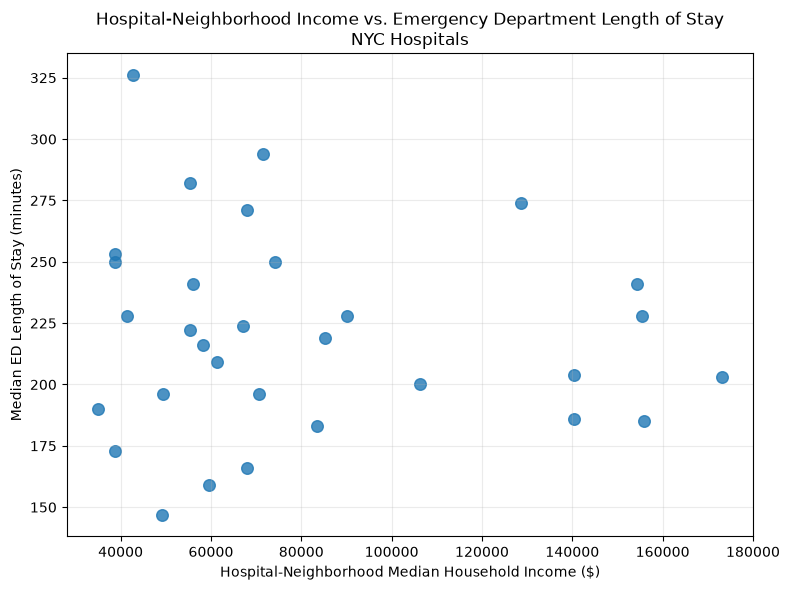

PRIMARY CORRELATION RESULTS
N = 31

Pearson correlation
r = -0.094
p-value = 0.6168

Spearman correlation
rho = -0.052
p-value = 0.7821

Pearson direction: Negative
Spearman direction: Negative


In [62]:
# ============================================================
# STEP 10 — PRIMARY RELATIONSHIP
# Scatterplot + Pearson + Spearman correlations
# ============================================================

# Install scipy if needed
%pip install scipy -q

import matplotlib.pyplot as plt
from scipy.stats import pearsonr, spearmanr

# X and Y
x = final_dataset["Median_Household_Income"]
y = final_dataset["ED_LOS_minutes"]

# ------------------------------------------------------------
# Scatterplot
# ------------------------------------------------------------

plt.figure(figsize=(8, 6))

plt.scatter(
    x,
    y,
    s=70,
    alpha=0.8
)

plt.xlabel("Hospital-Neighborhood Median Household Income ($)")
plt.ylabel("Median ED Length of Stay (minutes)")
plt.title(
    "Hospital-Neighborhood Income vs. Emergency Department Length of Stay\n"
    "NYC Hospitals"
)

plt.grid(alpha=0.25)

plt.tight_layout()

plt.savefig(
    "../output/income_vs_ed_los_scatter.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# Pearson correlation
# ------------------------------------------------------------

pearson_r, pearson_p = pearsonr(x, y)

# ------------------------------------------------------------
# Spearman correlation
# ------------------------------------------------------------

spearman_rho, spearman_p = spearmanr(x, y)


# ------------------------------------------------------------
# Results
# ------------------------------------------------------------

print("==============================================")
print("PRIMARY CORRELATION RESULTS")
print("==============================================")

print(f"N = {len(final_dataset)}")

print("\nPearson correlation")
print(f"r = {pearson_r:.3f}")
print(f"p-value = {pearson_p:.4f}")

print("\nSpearman correlation")
print(f"rho = {spearman_rho:.3f}")
print(f"p-value = {spearman_p:.4f}")


# ------------------------------------------------------------
# Simple direction interpretation
# ------------------------------------------------------------

if pearson_r < 0:
    print("\nPearson direction: Negative")
elif pearson_r > 0:
    print("\nPearson direction: Positive")
else:
    print("\nPearson direction: No linear relationship")

if spearman_rho < 0:
    print("Spearman direction: Negative")
elif spearman_rho > 0:
    print("Spearman direction: Positive")
else:
    print("Spearman direction: No monotonic relationship")

## Primary Relationship: Neighborhood Income and ED Length of Stay

The primary analysis examined whether hospital-neighborhood median household
income was associated with median emergency department length of stay among
31 New York City hospitals.

The Pearson correlation was **r = -0.094 (p = 0.617)**, indicating a very weak
negative linear association. The Spearman rank correlation was similarly small,
**ρ = -0.052 (p = 0.782)**.

Although both coefficients were negative, their magnitudes were close to zero.
Therefore, the data do not provide evidence of a meaningful association between
hospital-neighborhood median household income and ED length of stay in this
sample.

The scatterplot also shows substantial variation in ED length of stay across
hospitals with similar neighborhood income levels.

These findings do not support the original hypothesis that hospitals located in
higher-income neighborhoods would generally have shorter ED stays.

This analysis is observational and does not establish causation. In addition,
hospital-neighborhood median household income describes the socioeconomic
context of the hospital's location and should not be interpreted as the income
of patients receiving care at that hospital.

We found little evidence that the median household income of a hospital's surrounding ZIP/ZCTA was associated with ED length of stay among NYC hospitals.

And you can report:

Pearson: r = −0.09, p = .62
Spearman: ρ = −0.05, p = .78
N = 31 hospitals

### Interpretation of the Primary Correlation

The original hypothesis predicted that hospitals located in higher-income areas
would tend to have shorter emergency department stays. Although both correlation
coefficients were negative, the relationships were extremely weak
(Pearson r = -0.094; Spearman ρ = -0.052).

The large p-values indicate that the observed associations are not statistically
distinguishable from zero in this sample of 31 hospitals. The scatterplot also
shows substantial variation in ED length of stay among hospitals located in areas
with similar median household incomes.

This suggests that hospital-location income alone explains little of the
hospital-to-hospital variation in ED length of stay. Hospital characteristics,
workload, and other operational factors may be more important.

The result should also be interpreted cautiously because ZCTA median household
income describes the socioeconomic context of the hospital's location, not the
income of the patients treated there.




## Step 11 — Simple Linear Regression

A simple linear regression was used to quantify the association between
hospital-neighborhood median household income and median emergency department
length of stay.

Median household income was scaled in units of $10,000 so that the regression
coefficient could be interpreted as the predicted change in ED length of stay
associated with a $10,000 difference in hospital-neighborhood median household
income.

The model is:

ED Length of Stay = β₀ + β₁(Hospital-Neighborhood Income per $10,000) + ε

This is an observational analysis. The coefficient represents an association
and should not be interpreted as a causal effect.

In [64]:
# ============================================================
# STEP 11 — SIMPLE LINEAR REGRESSION
# No additional package installation required
# ============================================================

from scipy import stats
import pandas as pd

# 1. Prepare data
regression_data = final_dataset[
    ["Median_Household_Income", "ED_LOS_minutes"]
].dropna().copy()

# Scale income: 1 unit = $10,000
regression_data["Income_10k"] = (
    regression_data["Median_Household_Income"] / 10000
)

x = regression_data["Income_10k"]
y = regression_data["ED_LOS_minutes"]

# 2. Fit simple linear regression
result = stats.linregress(x, y)

slope = result.slope
intercept = result.intercept
p_value = result.pvalue
std_error = result.stderr
r_squared = result.rvalue ** 2
n = len(regression_data)

# 3. 95% confidence interval for slope
df = n - 2
t_critical = stats.t.ppf(0.975, df)

ci_lower = slope - (t_critical * std_error)
ci_upper = slope + (t_critical * std_error)

# 4. Print results
print("================================================")
print("SIMPLE LINEAR REGRESSION RESULTS")
print("================================================")

print(f"N = {n}")
print(f"Intercept (β0): {intercept:.2f} minutes")
print(f"Income coefficient (β1): {slope:.2f} minutes per $10,000")
print(f"95% CI for β1: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"p-value: {p_value:.4f}")
print(f"R-squared: {r_squared:.4f}")

print("\nInterpretation:")

if slope < 0:
    print(
        f"For each $10,000 increase in hospital-neighborhood "
        f"median household income, predicted ED length of stay "
        f"decreases by approximately {abs(slope):.2f} minutes."
    )
else:
    print(
        f"For each $10,000 increase in hospital-neighborhood "
        f"median household income, predicted ED length of stay "
        f"increases by approximately {slope:.2f} minutes."
    )

print("\nThis is an association, not a causal effect.")

# 5. Save results
regression_results = pd.DataFrame({
    "N": [n],
    "Intercept_minutes": [intercept],
    "Income_coefficient_per_10k": [slope],
    "CI_95_lower": [ci_lower],
    "CI_95_upper": [ci_upper],
    "p_value": [p_value],
    "R_squared": [r_squared]
})

regression_results.to_csv(
    "../output/simple_regression_results.csv",
    index=False
)

print("\nResults saved to:")
print("../output/simple_regression_results.csv")

SIMPLE LINEAR REGRESSION RESULTS
N = 31
Intercept (β0): 228.31 minutes
Income coefficient (β1): -0.93 minutes per $10,000
95% CI for β1: [-4.69, 2.83]
p-value: 0.6168
R-squared: 0.0087

Interpretation:
For each $10,000 increase in hospital-neighborhood median household income, predicted ED length of stay decreases by approximately 0.93 minutes.

This is an association, not a causal effect.

Results saved to:
../output/simple_regression_results.csv


### Interpretation of the Simple Regression

The simple linear regression estimated an income coefficient of
**β₁ = -0.93 minutes per $10,000 increase in hospital-neighborhood
median household income**.

This means that, on average, a $10,000 higher median household income
in the hospital's surrounding ZCTA was associated with approximately
0.93 fewer minutes of predicted emergency department length of stay.

However, the **95% confidence interval ranged from -4.69 to +2.83
minutes**, and the association was not statistically significant
(**p = 0.617**). Because the confidence interval includes zero, the
data are compatible with little or no association.

The model had an **R² of 0.0087**, meaning hospital-neighborhood median
household income explained approximately **0.87% of the observed
variation in ED length of stay** across the 31 hospitals.

Therefore, although the estimated coefficient was in the negative
direction predicted by the hypothesis, its magnitude was small and the
results do not provide evidence of a meaningful association between
hospital-neighborhood income and ED length of stay in this sample.

This analysis is observational and does not establish causation.
Hospital-neighborhood income represents the socioeconomic context of
the hospital's location and does not represent the income of the
patients treated there.

Each $10,000 increase in hospital-neighborhood median income was associated with 0.93 fewer ED minutes (95% CI: −4.69 to 2.83; p = .62; R² = .009; N = 31).

## Step 12 — Covariate Analysis

The primary analysis examined the unadjusted association between
hospital-neighborhood median household income and ED length of stay.

Several hospital characteristics may also contribute to differences in ED
performance. Available potential covariates include hospital ownership,
hospital overall rating, emergency department volume, and the percentage of
patients leaving without being seen (LWBS).

Before constructing an adjusted regression model, these variables are examined
to determine:

1. whether they contain sufficient variation,
2. whether substantial data are missing,
3. whether they are associated with ED length of stay,
4. whether they are associated with hospital-neighborhood income, and
5. whether their inclusion is conceptually and statistically reasonable given
   the small sample of 31 hospitals.

Hospital type and emergency-services status are not considered as predictors
because all hospitals in the analytic sample have the same values for those
variables.

These analyses are exploratory and are not used to select covariates solely
based on statistical significance.

In [65]:
# ============================================================
# STEP 12A — COVARIATE SCREENING
# ============================================================

from scipy import stats
import pandas as pd
import numpy as np

cov = final_dataset.copy()

# ------------------------------------------------------------
# 1. Simplify ownership for later modeling
# ------------------------------------------------------------

cov["Ownership_Group"] = np.where(
    cov["Hospital Ownership"].str.startswith("Government"),
    "Government",
    "Nonprofit"
)

print("================================================")
print("COVARIATE AVAILABILITY")
print("================================================")

covariates = [
    "Hospital overall rating",
    "Hospital Ownership",
    "Ownership_Group",
    "ED_Volume_Category",
    "LWBS_percent"
]

for var in covariates:
    print(
        f"{var}: "
        f"{cov[var].notna().sum()} available, "
        f"{cov[var].isna().sum()} missing"
    )


# ------------------------------------------------------------
# 2. Hospital rating
#    Rating is ordinal (1-5), so Spearman is emphasized.
# ------------------------------------------------------------

rating_los = cov[
    ["Hospital overall rating", "ED_LOS_minutes"]
].dropna()

rating_income = cov[
    ["Hospital overall rating", "Median_Household_Income"]
].dropna()

rating_los_rho, rating_los_p = stats.spearmanr(
    rating_los["Hospital overall rating"],
    rating_los["ED_LOS_minutes"]
)

rating_income_rho, rating_income_p = stats.spearmanr(
    rating_income["Hospital overall rating"],
    rating_income["Median_Household_Income"]
)

print("\n================================================")
print("HOSPITAL RATING")
print("================================================")

print(
    f"Rating vs ED LOS: "
    f"Spearman rho = {rating_los_rho:.3f}, "
    f"p = {rating_los_p:.4f}"
)

print(
    f"Rating vs Neighborhood Income: "
    f"Spearman rho = {rating_income_rho:.3f}, "
    f"p = {rating_income_p:.4f}"
)

rating_summary = (
    cov.groupby("Hospital overall rating")
    .agg(
        Hospitals=("Facility ID", "count"),
        Mean_ED_LOS=("ED_LOS_minutes", "mean"),
        Median_ED_LOS=("ED_LOS_minutes", "median"),
        Median_Income=("Median_Household_Income", "median")
    )
    .round(2)
)

display(rating_summary)


# ------------------------------------------------------------
# 3. Ownership
#    Use broader Government vs Nonprofit grouping because
#    several original ownership categories contain only 1-3 hospitals.
# ------------------------------------------------------------

print("\n================================================")
print("HOSPITAL OWNERSHIP")
print("================================================")

print("Original ownership categories:")
print(cov["Hospital Ownership"].value_counts())

print("\nBroader ownership grouping:")
print(cov["Ownership_Group"].value_counts())

ownership_summary = (
    cov.groupby("Ownership_Group")
    .agg(
        Hospitals=("Facility ID", "count"),
        Mean_ED_LOS=("ED_LOS_minutes", "mean"),
        Median_ED_LOS=("ED_LOS_minutes", "median"),
        Mean_Income=("Median_Household_Income", "mean"),
        Median_Income=("Median_Household_Income", "median")
    )
    .round(2)
)

display(ownership_summary)


# Exploratory Mann-Whitney comparisons
gov = cov[cov["Ownership_Group"] == "Government"]
nonprofit = cov[cov["Ownership_Group"] == "Nonprofit"]

ownership_los_test = stats.mannwhitneyu(
    gov["ED_LOS_minutes"],
    nonprofit["ED_LOS_minutes"],
    alternative="two-sided"
)

ownership_income_test = stats.mannwhitneyu(
    gov["Median_Household_Income"],
    nonprofit["Median_Household_Income"],
    alternative="two-sided"
)

print(
    f"Ownership group vs ED LOS: "
    f"Mann-Whitney p = {ownership_los_test.pvalue:.4f}"
)

print(
    f"Ownership group vs Neighborhood Income: "
    f"Mann-Whitney p = {ownership_income_test.pvalue:.4f}"
)


# ------------------------------------------------------------
# 4. ED volume
#    Primarily descriptive because categories are very unbalanced.
# ------------------------------------------------------------

print("\n================================================")
print("ED VOLUME CATEGORY")
print("================================================")

edv_summary = (
    cov.dropna(subset=["ED_Volume_Category"])
    .groupby("ED_Volume_Category")
    .agg(
        Hospitals=("Facility ID", "count"),
        Mean_ED_LOS=("ED_LOS_minutes", "mean"),
        Median_ED_LOS=("ED_LOS_minutes", "median"),
        Mean_Income=("Median_Household_Income", "mean"),
        Median_Income=("Median_Household_Income", "median")
    )
    .round(2)
)

display(edv_summary)

print(
    "\nNote: ED volume is treated primarily descriptively because "
    "the categories are highly unbalanced."
)


# ------------------------------------------------------------
# 5. Left Without Being Seen (LWBS)
# ------------------------------------------------------------

lwbs_data = cov[
    [
        "LWBS_percent",
        "ED_LOS_minutes",
        "Median_Household_Income"
    ]
].dropna()

lwbs_los_rho, lwbs_los_p = stats.spearmanr(
    lwbs_data["LWBS_percent"],
    lwbs_data["ED_LOS_minutes"]
)

lwbs_income_rho, lwbs_income_p = stats.spearmanr(
    lwbs_data["LWBS_percent"],
    lwbs_data["Median_Household_Income"]
)

print("\n================================================")
print("LEFT WITHOUT BEING SEEN (LWBS)")
print("================================================")

print(f"N with LWBS data = {len(lwbs_data)}")

print(
    f"LWBS vs ED LOS: "
    f"Spearman rho = {lwbs_los_rho:.3f}, "
    f"p = {lwbs_los_p:.4f}"
)

print(
    f"LWBS vs Neighborhood Income: "
    f"Spearman rho = {lwbs_income_rho:.3f}, "
    f"p = {lwbs_income_p:.4f}"
)


# ------------------------------------------------------------
# 6. How many hospitals would remain in possible adjusted models?
# ------------------------------------------------------------

model_basic = cov[
    [
        "ED_LOS_minutes",
        "Median_Household_Income",
        "Hospital overall rating",
        "Ownership_Group"
    ]
].dropna()

model_with_edv = cov[
    [
        "ED_LOS_minutes",
        "Median_Household_Income",
        "Hospital overall rating",
        "Ownership_Group",
        "ED_Volume_Category"
    ]
].dropna()

model_with_lwbs = cov[
    [
        "ED_LOS_minutes",
        "Median_Household_Income",
        "Hospital overall rating",
        "Ownership_Group",
        "LWBS_percent"
    ]
].dropna()

print("\n================================================")
print("POTENTIAL ADJUSTED MODEL SAMPLE SIZES")
print("================================================")

print(
    "Income + Rating + Ownership:",
    len(model_basic)
)

print(
    "Income + Rating + Ownership + ED Volume:",
    len(model_with_edv)
)

print(
    "Income + Rating + Ownership + LWBS:",
    len(model_with_lwbs)
)

COVARIATE AVAILABILITY
Hospital overall rating: 31 available, 0 missing
Hospital Ownership: 31 available, 0 missing
Ownership_Group: 31 available, 0 missing
ED_Volume_Category: 28 available, 3 missing
LWBS_percent: 28 available, 3 missing

HOSPITAL RATING
Rating vs ED LOS: Spearman rho = 0.006, p = 0.9757
Rating vs Neighborhood Income: Spearman rho = 0.249, p = 0.1768


,Hospitals,Mean_ED_LOS,Median_ED_LOS,Median_Income
Hospital overall rating,,,,
1,9,227.33,228.0,67897.0
2,12,215.17,217.5,64229.0
3,4,198.25,189.5,66371.5
4,2,262.00,262.0,83627.0
5,4,224.75,216.0,147856.0



HOSPITAL OWNERSHIP
Original ownership categories:
Hospital Ownership
Voluntary non-profit - Private    18
Government - Local                 7
Voluntary non-profit - Other       3
Government - State                 2
Voluntary non-profit - Church      1
Name: count, dtype: int64

Broader ownership grouping:
Ownership_Group
Nonprofit     22
Government     9
Name: count, dtype: int64


,Hospitals,Mean_ED_LOS,Median_ED_LOS,Mean_Income,Median_Income
Ownership_Group,,,,,
Government,9,213.67,209.0,66970.11,67028.0
Nonprofit,22,223.68,220.5,86777.14,72349.5


Ownership group vs ED LOS: Mann-Whitney p = 0.5566
Ownership group vs Neighborhood Income: Mann-Whitney p = 0.3273

ED VOLUME CATEGORY


,Hospitals,Mean_ED_LOS,Median_ED_LOS,Mean_Income,Median_Income
ED_Volume_Category,,,,,
high,4,202.50,201.5,100854.50,87073.5
medium,2,237.50,237.5,47048.00,47048.0
very high,22,223.59,221.5,83505.41,69254.0



Note: ED volume is treated primarily descriptively because the categories are highly unbalanced.

LEFT WITHOUT BEING SEEN (LWBS)
N with LWBS data = 28
LWBS vs ED LOS: Spearman rho = 0.378, p = 0.0476
LWBS vs Neighborhood Income: Spearman rho = -0.460, p = 0.0137

POTENTIAL ADJUSTED MODEL SAMPLE SIZES
Income + Rating + Ownership: 31
Income + Rating + Ownership + ED Volume: 28
Income + Rating + Ownership + LWBS: 28


In [66]:
print("RATING")
print(f"Rating vs ED LOS: rho = {rating_los_rho:.3f}, p = {rating_los_p:.4f}")
print(f"Rating vs Income: rho = {rating_income_rho:.3f}, p = {rating_income_p:.4f}")

print("\nOWNERSHIP")
display(ownership_summary)

print(f"Ownership vs ED LOS: p = {ownership_los_test.pvalue:.4f}")
print(f"Ownership vs Income: p = {ownership_income_test.pvalue:.4f}")

RATING
Rating vs ED LOS: rho = 0.006, p = 0.9757
Rating vs Income: rho = 0.249, p = 0.1768

OWNERSHIP


,Hospitals,Mean_ED_LOS,Median_ED_LOS,Mean_Income,Median_Income
Ownership_Group,,,,,
Government,9,213.67,209.0,66970.11,67028.0
Nonprofit,22,223.68,220.5,86777.14,72349.5


Ownership vs ED LOS: p = 0.5566
Ownership vs Income: p = 0.3273


In [67]:
print(f"Rating vs ED LOS: rho = {rating_los_rho:.3f}, p = {rating_los_p:.4f}")
print(f"Rating vs Income: rho = {rating_income_rho:.3f}, p = {rating_income_p:.4f}")

Rating vs ED LOS: rho = 0.006, p = 0.9757
Rating vs Income: rho = 0.249, p = 0.1768


In [68]:
# ============================================================
# STEP 12B — ADJUSTED LINEAR REGRESSION
# Income + Ownership + Hospital Rating
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

adjusted = cov[
    [
        "ED_LOS_minutes",
        "Median_Household_Income",
        "Ownership_Group",
        "Hospital overall rating"
    ]
].dropna().copy()

# Scale income: 1 unit = $10,000
adjusted["Income_10k"] = (
    adjusted["Median_Household_Income"] / 10000
)

# Ownership coding:
# Government = 1
# Nonprofit = 0
adjusted["Government"] = (
    adjusted["Ownership_Group"] == "Government"
).astype(int)

# Outcome
y = adjusted["ED_LOS_minutes"].to_numpy(dtype=float)

# Predictor matrix
X = np.column_stack([
    np.ones(len(adjusted)),
    adjusted["Income_10k"],
    adjusted["Government"],
    adjusted["Hospital overall rating"]
])

names = [
    "Intercept",
    "Income per $10,000",
    "Government ownership",
    "Hospital rating"
]

# Fit OLS
beta = np.linalg.lstsq(X, y, rcond=None)[0]

y_hat = X @ beta
residuals = y - y_hat

n = len(y)
p = X.shape[1]
df = n - p

# Residual variance
SSE = np.sum(residuals ** 2)
sigma2 = SSE / df

# Variance-covariance matrix
XtX_inv = np.linalg.inv(X.T @ X)
var_beta = sigma2 * XtX_inv
se_beta = np.sqrt(np.diag(var_beta))

# t statistics and p-values
t_stats = beta / se_beta
p_values = 2 * (
    1 - stats.t.cdf(np.abs(t_stats), df=df)
)

# 95% confidence intervals
t_crit = stats.t.ppf(0.975, df)

ci_lower = beta - t_crit * se_beta
ci_upper = beta + t_crit * se_beta

# R-squared
SST = np.sum((y - y.mean()) ** 2)
r_squared = 1 - SSE / SST

# Adjusted R-squared
adj_r_squared = 1 - (
    (1 - r_squared) *
    (n - 1) /
    (n - p)
)

results = pd.DataFrame({
    "Coefficient": beta,
    "Std_Error": se_beta,
    "95% CI Lower": ci_lower,
    "95% CI Upper": ci_upper,
    "t": t_stats,
    "p_value": p_values
}, index=names)

print("================================================")
print("ADJUSTED REGRESSION RESULTS")
print("================================================")

print(f"N = {n}")
print(f"R-squared = {r_squared:.4f}")
print(f"Adjusted R-squared = {adj_r_squared:.4f}")

display(results.round(4))

print("\nIncome interpretation:")
print(
    f"After adjusting for ownership and hospital rating, "
    f"each $10,000 increase in hospital-neighborhood income "
    f"is associated with a {beta[1]:.2f}-minute change "
    f"in predicted ED length of stay."
)

print(
    f"95% CI: [{ci_lower[1]:.2f}, {ci_upper[1]:.2f}]"
)

print(
    f"p-value: {p_values[1]:.4f}"
)

ADJUSTED REGRESSION RESULTS
N = 31
R-squared = 0.0318
Adjusted R-squared = -0.0758


,Coefficient,Std_Error,95% CI Lower,95% CI Upper,t,p_value
Intercept,231.0355,21.2897,187.3526,274.7184,10.8520,0.0000
"Income per $10,000",-1.5349,2.1062,-5.8565,2.7867,-0.7288,0.4724
Government ownership,-11.5165,17.5658,-47.5585,24.5254,-0.6556,0.5176
Hospital rating,2.3437,6.5816,-11.1605,15.8480,0.3561,0.7245



Income interpretation:
After adjusting for ownership and hospital rating, each $10,000 increase in hospital-neighborhood income is associated with a -1.53-minute change in predicted ED length of stay.
95% CI: [-5.86, 2.79]
p-value: 0.4724


### Adjusted Regression Interpretation

An exploratory adjusted regression was used to examine whether the estimated
association between hospital-neighborhood income and ED length of stay changed
after accounting for hospital ownership and overall hospital rating.

In the unadjusted model, each $10,000 increase in hospital-neighborhood median
household income was associated with approximately 0.93 fewer minutes of
predicted ED length of stay.

After adjustment for ownership and hospital rating, the estimated association
was slightly larger in magnitude but remained weak:

**β = -1.53 minutes per $10,000**
**95% CI: -5.86 to 2.79**
**p = 0.472**

Therefore, adjustment for these hospital characteristics did not materially
change the conclusion of the primary analysis.

The adjusted model had an R² of 0.0318, meaning approximately 3.2% of the
observed variation in ED length of stay was explained collectively by
neighborhood income, ownership, and hospital rating.

The adjusted R² was -0.0758, indicating that the additional predictors did not
improve explanatory performance after accounting for model complexity.

Neither government ownership nor hospital rating showed a statistically
detectable association with ED length of stay in this small sample.

Overall, the adjusted analysis provides no evidence that hospital-neighborhood
median household income is meaningfully associated with ED length of stay after
accounting for these available hospital characteristics.

These results describe observational associations and should not be interpreted
causally.

In [69]:
# ============================================================
# STEP 12C — SECONDARY LWBS SENSITIVITY MODEL
# ============================================================

import numpy as np
import pandas as pd
from scipy import stats

lwbs_model = final_dataset[
    [
        "ED_LOS_minutes",
        "Median_Household_Income",
        "LWBS_percent"
    ]
].dropna().copy()

lwbs_model["Income_10k"] = (
    lwbs_model["Median_Household_Income"] / 10000
)

y = lwbs_model["ED_LOS_minutes"].to_numpy(dtype=float)

X = np.column_stack([
    np.ones(len(lwbs_model)),
    lwbs_model["Income_10k"],
    lwbs_model["LWBS_percent"]
])

names = [
    "Intercept",
    "Income per $10,000",
    "LWBS percent"
]

# Fit OLS
beta = np.linalg.lstsq(X, y, rcond=None)[0]

y_hat = X @ beta
residuals = y - y_hat

n = len(y)
p = X.shape[1]
df = n - p

SSE = np.sum(residuals ** 2)
SST = np.sum((y - y.mean()) ** 2)

r_squared = 1 - SSE / SST

adj_r_squared = 1 - (
    (1 - r_squared) *
    (n - 1) /
    (n - p)
)

sigma2 = SSE / df

XtX_inv = np.linalg.inv(X.T @ X)

var_beta = sigma2 * XtX_inv

se_beta = np.sqrt(
    np.diag(var_beta)
)

t_stats = beta / se_beta

p_values = 2 * (
    1 - stats.t.cdf(
        np.abs(t_stats),
        df=df
    )
)

t_crit = stats.t.ppf(
    0.975,
    df
)

ci_lower = beta - t_crit * se_beta
ci_upper = beta + t_crit * se_beta

results_lwbs = pd.DataFrame({
    "Coefficient": beta,
    "Std_Error": se_beta,
    "95% CI Lower": ci_lower,
    "95% CI Upper": ci_upper,
    "p_value": p_values
}, index=names)

print("================================================")
print("LWBS SENSITIVITY REGRESSION")
print("================================================")

print(f"N = {n}")
print(f"R-squared = {r_squared:.4f}")
print(f"Adjusted R-squared = {adj_r_squared:.4f}")

display(results_lwbs.round(4))

print("\nIncome coefficient comparison:")
print("Unadjusted income coefficient: -0.93 minutes per $10,000")
print("Ownership/rating adjusted coefficient: -1.53 minutes per $10,000")
print(
    f"LWBS-adjusted coefficient: "
    f"{beta[1]:.2f} minutes per $10,000"
)

LWBS SENSITIVITY REGRESSION
N = 28
R-squared = 0.2468
Adjusted R-squared = 0.1865


,Coefficient,Std_Error,95% CI Lower,95% CI Upper,p_value
Intercept,191.7432,21.4911,147.4814,236.0050,0.0000
"Income per $10,000",0.6249,1.8103,-3.1035,4.3532,0.7329
LWBS percent,9.9900,3.6298,2.5143,17.4657,0.0109



Income coefficient comparison:
Unadjusted income coefficient: -0.93 minutes per $10,000
Ownership/rating adjusted coefficient: -1.53 minutes per $10,000
LWBS-adjusted coefficient: 0.62 minutes per $10,000


### LWBS Sensitivity Analysis

A secondary sensitivity model examined hospital-level Left Without Being Seen
(LWBS) percentage because LWBS was associated with both ED length of stay and
hospital-neighborhood income.

After adjustment for LWBS, the estimated income coefficient changed from
-0.93 minutes per $10,000 in the unadjusted analysis to +0.62 minutes per
$10,000.

The adjusted income association remained very small and was not statistically
significant (95% CI: -3.10 to 4.35; p = 0.733). Therefore, the overall
conclusion regarding hospital-neighborhood income did not change.

LWBS itself showed a stronger association with ED length of stay. A
one-percentage-point increase in LWBS was associated with approximately
10 additional minutes of predicted ED length of stay (95% CI: 2.51 to 17.47;
p = 0.011).

The model explained approximately 24.7% of the observed variation in ED length
of stay (adjusted R² = 0.187).

This LWBS analysis is considered secondary because LWBS is itself an emergency
department operational outcome and may reflect the same underlying congestion
or workload processes that contribute to longer ED stays. The association
should not be interpreted causally. The model also included only 28 hospitals
because three facilities had unavailable LWBS data.

INCOME QUARTILE SUMMARY


,Hospitals,Median_Income,Mean_ED_LOS,Median_ED_LOS
Income_Quartile,,,,
Q1 - Lowest,8,40062.5,220.38,212.0
Q2,9,59661.0,221.11,222.0
Q3,6,78754.5,228.33,223.5
Q4 - Highest,8,147321.5,215.12,203.5



INCOME RANGE WITHIN EACH QUARTILE


,Minimum_Income,Maximum_Income
Income_Quartile,,
Q1 - Lowest,34954.0,49330.0
Q2,55326.0,67897.0
Q3,70603.0,90156.0
Q4 - Highest,106250.0,173136.0


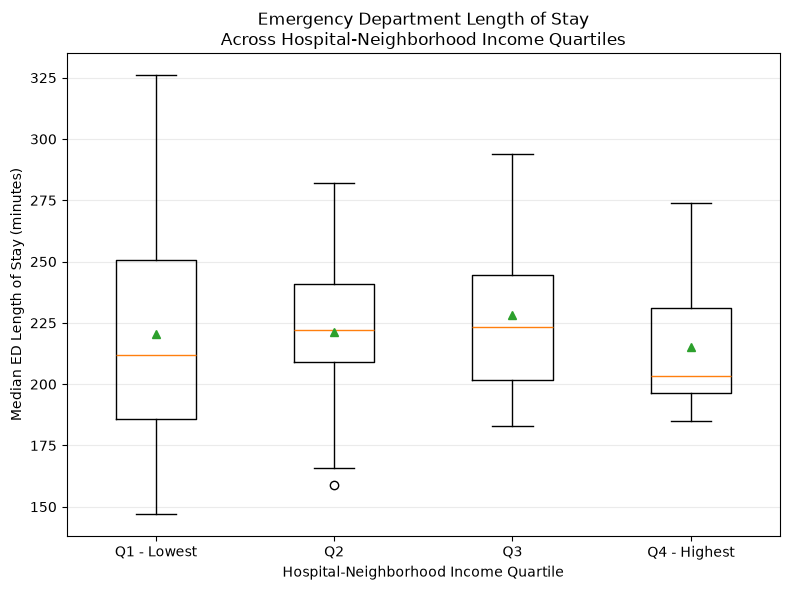


Quartile summary and boxplot saved in the output folder.


In [70]:
# ============================================================
# STEP 13 — INCOME QUARTILES
# ============================================================

import pandas as pd
import matplotlib.pyplot as plt

quartile_data = final_dataset.copy()

# ------------------------------------------------------------
# 1. Create income quartiles
# ------------------------------------------------------------

quartile_data["Income_Quartile"] = pd.qcut(
    quartile_data["Median_Household_Income"],
    q=4,
    labels=[
        "Q1 - Lowest",
        "Q2",
        "Q3",
        "Q4 - Highest"
    ]
)


# ------------------------------------------------------------
# 2. Quartile summary
# ------------------------------------------------------------

quartile_summary = (
    quartile_data
    .groupby("Income_Quartile", observed=True)
    .agg(
        Hospitals=("Facility ID", "count"),
        Median_Income=("Median_Household_Income", "median"),
        Mean_ED_LOS=("ED_LOS_minutes", "mean"),
        Median_ED_LOS=("ED_LOS_minutes", "median")
    )
    .round(2)
)

print("================================================")
print("INCOME QUARTILE SUMMARY")
print("================================================")

display(quartile_summary)


# ------------------------------------------------------------
# 3. Show income ranges for each quartile
# ------------------------------------------------------------

quartile_ranges = (
    quartile_data
    .groupby("Income_Quartile", observed=True)
    .agg(
        Minimum_Income=("Median_Household_Income", "min"),
        Maximum_Income=("Median_Household_Income", "max")
    )
    .round(2)
)

print("\n================================================")
print("INCOME RANGE WITHIN EACH QUARTILE")
print("================================================")

display(quartile_ranges)


# ------------------------------------------------------------
# 4. Boxplot of ED LOS by income quartile
# ------------------------------------------------------------

order = [
    "Q1 - Lowest",
    "Q2",
    "Q3",
    "Q4 - Highest"
]

plot_data = [
    quartile_data.loc[
        quartile_data["Income_Quartile"] == group,
        "ED_LOS_minutes"
    ]
    for group in order
]

plt.figure(figsize=(8, 6))

plt.boxplot(
    plot_data,
    tick_labels=order,
    showmeans=True
)

plt.xlabel("Hospital-Neighborhood Income Quartile")
plt.ylabel("Median ED Length of Stay (minutes)")
plt.title(
    "Emergency Department Length of Stay\n"
    "Across Hospital-Neighborhood Income Quartiles"
)

plt.grid(axis="y", alpha=0.25)

plt.tight_layout()

plt.savefig(
    "../output/ed_los_by_income_quartile.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()


# ------------------------------------------------------------
# 5. Save quartile results
# ------------------------------------------------------------

quartile_summary.to_csv(
    "../output/income_quartile_summary.csv"
)

quartile_ranges.to_csv(
    "../output/income_quartile_ranges.csv"
)

print("\nQuartile summary and boxplot saved in the output folder.")

### Interpretation of Income Quartiles

The quartile analysis did not show a consistent decrease in ED length of stay
as hospital-neighborhood income increased.

Mean ED length of stay was 220.4 minutes in Q1, 221.1 minutes in Q2,
228.3 minutes in Q3, and 215.1 minutes in Q4.

Although hospitals in the highest-income quartile had the lowest mean and
median ED length of stay, the pattern across all four quartiles was not
monotonic. In particular, hospitals in Q3 had the highest average ED length
of stay.

Therefore, the quartile analysis is consistent with the correlation and
regression results: hospital-neighborhood income does not appear to have a
strong or systematic association with ED length of stay in this sample.

This comparison is descriptive and should not be interpreted causally.
Hospital-neighborhood income represents the socioeconomic context of the
hospital's location rather than the socioeconomic characteristics of its
patients.

In [71]:
# ============================================================
# STEP 14 — SENSITIVITY ANALYSIS
# ============================================================

from scipy import stats
import pandas as pd
import numpy as np

sensitivity_data = final_dataset.copy()


def run_simple_analysis(data, label):
    x = data["Median_Household_Income"] / 10000
    y = data["ED_LOS_minutes"]

    reg = stats.linregress(x, y)
    pearson = stats.pearsonr(x, y)
    spearman = stats.spearmanr(x, y)

    return {
        "Analysis": label,
        "N": len(data),
        "Slope_per_$10k": reg.slope,
        "Pearson_r": pearson.statistic,
        "Pearson_p": pearson.pvalue,
        "Spearman_rho": spearman.statistic,
        "Spearman_p": spearman.pvalue,
        "R_squared": reg.rvalue ** 2
    }


# ------------------------------------------------------------
# 1. Original analysis
# ------------------------------------------------------------

results = []

results.append(
    run_simple_analysis(
        sensitivity_data,
        "Full sample"
    )
)


# ------------------------------------------------------------
# 2. Remove ED LOS outlier only
# ------------------------------------------------------------

no_los_outlier = sensitivity_data[
    sensitivity_data["Facility Name"] != "ST BARNABAS HOSPITAL"
]

results.append(
    run_simple_analysis(
        no_los_outlier,
        "Without St. Barnabas"
    )
)


# ------------------------------------------------------------
# 3. Remove income outlier only
# ------------------------------------------------------------

no_income_outlier = sensitivity_data[
    sensitivity_data["Facility Name"] !=
    "BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS"
]

results.append(
    run_simple_analysis(
        no_income_outlier,
        "Without Brooklyn Hospital Downtown"
    )
)


# ------------------------------------------------------------
# 4. Remove both flagged observations
# ------------------------------------------------------------

without_both = sensitivity_data[
    ~sensitivity_data["Facility Name"].isin([
        "ST BARNABAS HOSPITAL",
        "BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS"
    ])
]

results.append(
    run_simple_analysis(
        without_both,
        "Without both flagged hospitals"
    )
)


# ------------------------------------------------------------
# 5. Display sensitivity table
# ------------------------------------------------------------

sensitivity_results = pd.DataFrame(results)

print("================================================")
print("SENSITIVITY ANALYSIS")
print("================================================")

display(
    sensitivity_results.round(4)
)


# ------------------------------------------------------------
# 6. Leave-one-hospital-out regression
# ------------------------------------------------------------

loo_results = []

for facility in sensitivity_data["Facility Name"]:

    subset = sensitivity_data[
        sensitivity_data["Facility Name"] != facility
    ]

    x = subset["Median_Household_Income"] / 10000
    y = subset["ED_LOS_minutes"]

    reg = stats.linregress(x, y)

    loo_results.append({
        "Hospital_Removed": facility,
        "Slope_per_$10k": reg.slope,
        "Pearson_r": reg.rvalue,
        "p_value": reg.pvalue
    })

loo_results = pd.DataFrame(loo_results)


print("\n================================================")
print("LEAVE-ONE-HOSPITAL-OUT RANGE")
print("================================================")

print(
    "Smallest income slope:",
    round(loo_results["Slope_per_$10k"].min(), 2)
)

print(
    "Largest income slope:",
    round(loo_results["Slope_per_$10k"].max(), 2)
)

print(
    "Smallest Pearson r:",
    round(loo_results["Pearson_r"].min(), 3)
)

print(
    "Largest Pearson r:",
    round(loo_results["Pearson_r"].max(), 3)
)


# Hospitals causing largest slope changes
print("\nHospitals with the most extreme leave-one-out slopes:")

display(
    pd.concat([
        loo_results.nsmallest(3, "Slope_per_$10k"),
        loo_results.nlargest(3, "Slope_per_$10k")
    ]).drop_duplicates()
)


# Save
sensitivity_results.to_csv(
    "../output/sensitivity_analysis.csv",
    index=False
)

loo_results.to_csv(
    "../output/leave_one_out_analysis.csv",
    index=False
)

SENSITIVITY ANALYSIS


,Analysis,N,Slope_per_$10k,Pearson_r,Pearson_p,Spearman_rho,Spearman_p,R_squared
0,Full sample,31,-0.9300,-0.0935,0.6168,-0.0518,0.7821,0.0087
1,Without St. Barnabas,30,-0.1267,-0.0143,0.9404,0.0141,0.9409,0.0002
2,Without Brooklyn Hospital Downtown,30,-0.7257,-0.0667,0.7262,-0.0308,0.8714,0.0044
3,Without both flagged hospitals,29,0.1694,0.0174,0.9286,0.0384,0.8434,0.0003



LEAVE-ONE-HOSPITAL-OUT RANGE
Smallest income slope: -1.5
Largest income slope: -0.13
Smallest Pearson r: -0.152
Largest Pearson r: -0.014

Hospitals with the most extreme leave-one-out slopes:


,Hospital_Removed,Slope_per_$10k,Pearson_r,p_value
5,MOUNT SINAI WEST,-1.503978,-0.152197,0.422040
26,HARLEM HOSPITAL CENTER,-1.429360,-0.150799,0.426364
19,METROPOLITAN HOSPITAL CENTER,-1.384101,-0.139926,0.460831
30,ST BARNABAS HOSPITAL,-0.126732,-0.014251,0.940419
11,LENOX HILL HOSPITAL,-0.444040,-0.042627,0.823023
21,BELLEVUE HOSPITAL CENTER,-0.556381,-0.054610,0.774405


### Sensitivity Analysis Interpretation

Sensitivity analyses were conducted to determine whether the primary findings
were driven by unusual or influential hospitals.

In the full sample, the estimated association was -0.93 minutes of ED length
of stay per $10,000 increase in hospital-neighborhood median household income.

After excluding St. Barnabas Hospital, which was identified as an ED
length-of-stay outlier, the estimated slope decreased in magnitude to
-0.13 minutes per $10,000.

After excluding Brooklyn Hospital Center–Downtown Campus, which was identified
as an income outlier, the slope was -0.73 minutes per $10,000.

When both flagged hospitals were excluded, the estimated slope became slightly
positive (+0.17 minutes per $10,000). In all cases, correlations remained very
close to zero and were not statistically significant.

A leave-one-hospital-out analysis also showed that removing any single hospital
produced slopes ranging from approximately -1.50 to -0.13 minutes per $10,000.
No single hospital changed the overall conclusion.

These analyses indicate that the main finding is robust: there is little
evidence of a consistent association between hospital-neighborhood median
household income and ED length of stay among the NYC hospitals in this sample.

The sensitivity results also suggest that the direction of the very small
income coefficient should not be emphasized because it changes under reasonable
alternative specifications.

In [72]:
# ============================================================
# STEP 15 — REPRESENTATIVE HOSPITAL CASE STUDIES
# ============================================================

import numpy as np
import pandas as pd

case_data = final_dataset.sort_values(
    ["Median_Household_Income", "Facility Name"]
).reset_index(drop=True)

# Select five evenly spaced positions in the income distribution
positions = np.round(
    np.linspace(0, len(case_data) - 1, 5)
).astype(int)

labels = [
    "Low-income location",
    "Lower-middle",
    "Middle",
    "Upper-middle",
    "High-income location"
]

representative_hospitals = (
    case_data.iloc[positions]
    .copy()
)

representative_hospitals.insert(
    0,
    "Income_Position",
    labels
)

case_studies = representative_hospitals[
    [
        "Income_Position",
        "Facility Name",
        "Borough",
        "ZIP Code",
        "Median_Household_Income",
        "ED_LOS_minutes",
        "ED_Volume_Category",
        "Hospital Ownership",
        "Hospital overall rating"
    ]
]

print("================================================")
print("REPRESENTATIVE HOSPITAL CASE STUDIES")
print("================================================")

display(case_studies)

case_studies.to_csv(
    "../output/representative_hospitals.csv",
    index=False
)

REPRESENTATIVE HOSPITAL CASE STUDIES


,Income_Position,Facility Name,Borough,ZIP Code,Median_Household_Income,ED_LOS_minutes,ED_Volume_Category,Hospital Ownership,Hospital overall rating
0,Low-income location,BRONXCARE HOSPITAL CENTER,Bronx,10456,34954.0,190.0,very high,Voluntary non-profit - Private,1
8,Lower-middle,FLUSHING HOSPITAL MEDICAL CENTER,Queens,11355,55326.0,222.0,medium,Voluntary non-profit - Private,2
15,Middle,KINGS COUNTY HOSPITAL CENTER,Brooklyn,11203,67897.0,271.0,NaN,Government - Local,1
22,Upper-middle,JAMAICA HOSPITAL MEDICAL CENTER,Queens,11418,90156.0,228.0,very high,Voluntary non-profit - Private,1
30,High-income location,BROOKLYN HOSPITAL CENTER - DOWNTOWN CAMPUS,Brooklyn,11201,173136.0,203.0,high,Voluntary non-profit - Other,2
